# Combined Experimental Tracking Lab

This notebook combines the idea of **basic experiment tracking** and **model comparison** into one simple workflow.

**What is different here?**
- **Dataset:** Breast Cancer Wisconsin dataset from `scikit-learn`
- **Model:** `RandomForestClassifier`
- **Tracking:** W&B in **offline** mode, so the notebook can still run locally without needing an online login

This is a simple notebook prepared as part of the **Experimental Tracking Lab**.


In [1]:
import os
os.environ["WANDB_MODE"] = "offline"
os.environ["WANDB_SILENT"] = "true"

from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.inspection import permutation_importance
import joblib

warnings.filterwarnings("ignore")

try:
    import wandb
    WANDB_AVAILABLE = True
    print("wandb available: using offline tracking mode")
except Exception as e:
    WANDB_AVAILABLE = False
    wandb = None
    print(f"wandb not available: continuing without it ({e})")

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)


wandb not available: continuing without it (No module named 'wandb')


## 1. Load a different dataset

In [2]:
dataset = load_breast_cancer(as_frame=True)
X = dataset.data.copy()
y = dataset.target.copy()

df = X.copy()
df["target"] = y.map({0: "malignant", 1: "benign"})

print("Dataset shape:", df.shape)
print("Target names:", list(dataset.target_names))
print("\nClass distribution:")
print(df["target"].value_counts())

df.head()


Dataset shape: (569, 31)
Target names: ['malignant', 'benign']

Class distribution:
target
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


## 2. Train/test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])
print("Number of features:", X_train.shape[1])


Training samples: 455
Test samples: 114
Number of features: 30


## 3. Run tracked experiments

In [4]:
experiments = [
    {"run_name": "rf_depth_4", "n_estimators": 120, "max_depth": 4, "min_samples_split": 2, "random_state": 42},
    {"run_name": "rf_depth_8", "n_estimators": 180, "max_depth": 8, "min_samples_split": 4, "random_state": 42},
    {"run_name": "rf_depth_none", "n_estimators": 220, "max_depth": None, "min_samples_split": 2, "random_state": 42},
]

all_results = []
trained_models = {}

def run_experiment(config):
    run = None
    if WANDB_AVAILABLE:
        run = wandb.init(
            project="experimental-tracking-lab-combined",
            name=config["run_name"],
            config=config,
            reinit=True,
            mode="offline",
        )

    model = RandomForestClassifier(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_split=config["min_samples_split"],
        random_state=config["random_state"],
    )
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy": float(accuracy_score(y_test, preds)),
        "precision": float(precision_score(y_test, preds)),
        "recall": float(recall_score(y_test, preds)),
        "f1_score": float(f1_score(y_test, preds)),
        "roc_auc": float(roc_auc_score(y_test, probs)),
    }

    result = dict(config)
    result.update(metrics)
    all_results.append(result)
    trained_models[config["run_name"]] = model

    metrics_path = output_dir / f"{config['run_name']}_metrics.json"
    with open(metrics_path, "w") as f:
        json.dump(result, f, indent=2)

    model_path = output_dir / f"{config['run_name']}_model.joblib"
    joblib.dump(model, model_path)

    if WANDB_AVAILABLE and run is not None:
        wandb.log(metrics)
        wandb.summary.update(metrics)
        run.finish()

    print(f"Finished {config['run_name']}: accuracy={metrics['accuracy']:.4f}, f1={metrics['f1_score']:.4f}, roc_auc={metrics['roc_auc']:.4f}")

for config in experiments:
    run_experiment(config)


Finished rf_depth_4: accuracy=0.9474, f1=0.9583, roc_auc=0.9940
Finished rf_depth_8: accuracy=0.9474, f1=0.9583, roc_auc=0.9931
Finished rf_depth_none: accuracy=0.9561, f1=0.9655, roc_auc=0.9932


## 4. Compare experiment results

In [5]:
results_df = pd.DataFrame(all_results).sort_values(
    by=["accuracy", "f1_score", "roc_auc"], ascending=False
).reset_index(drop=True)

results_df


,run_name,n_estimators,max_depth,min_samples_split,random_state,accuracy,precision,recall,f1_score,roc_auc
0,rf_depth_none,220,NaN,2,42,0.956140,0.958904,0.972222,0.965517,0.993221
1,rf_depth_4,120,4.0,2,42,0.947368,0.958333,0.958333,0.958333,0.994048
2,rf_depth_8,180,8.0,4,42,0.947368,0.958333,0.958333,0.958333,0.993056


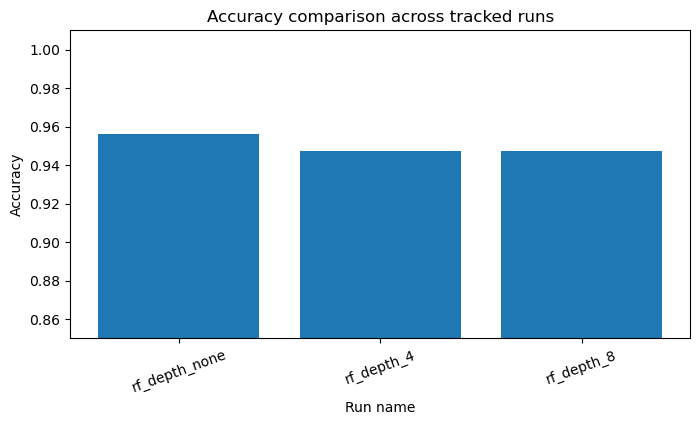

In [6]:
plt.figure(figsize=(8, 4))
plt.bar(results_df["run_name"], results_df["accuracy"])
plt.ylim(0.85, 1.01)
plt.xlabel("Run name")
plt.ylabel("Accuracy")
plt.title("Accuracy comparison across tracked runs")
plt.xticks(rotation=20)
plt.show()


## 5. Confusion matrix for the best run

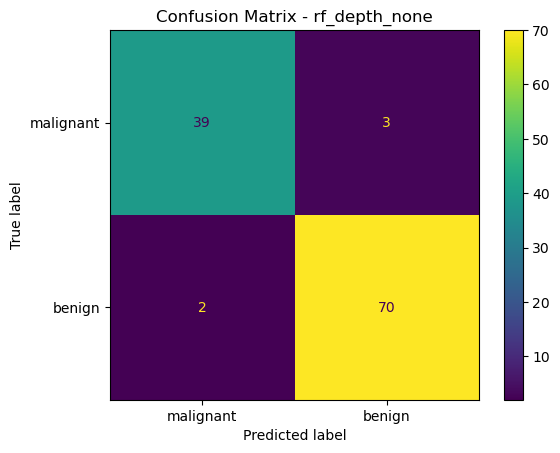

Best run: rf_depth_none
accuracy      0.95614
precision    0.958904
recall       0.972222
f1_score     0.965517
roc_auc      0.993221
Name: 0, dtype: object


In [7]:
best_run_name = results_df.iloc[0]["run_name"]
best_model = trained_models[best_run_name]
best_preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.target_names)
disp.plot()
plt.title(f"Confusion Matrix - {best_run_name}")
plt.show()

print("Best run:", best_run_name)
print(results_df.iloc[0][["accuracy", "precision", "recall", "f1_score", "roc_auc"]])


## 6. Feature importance from the best model

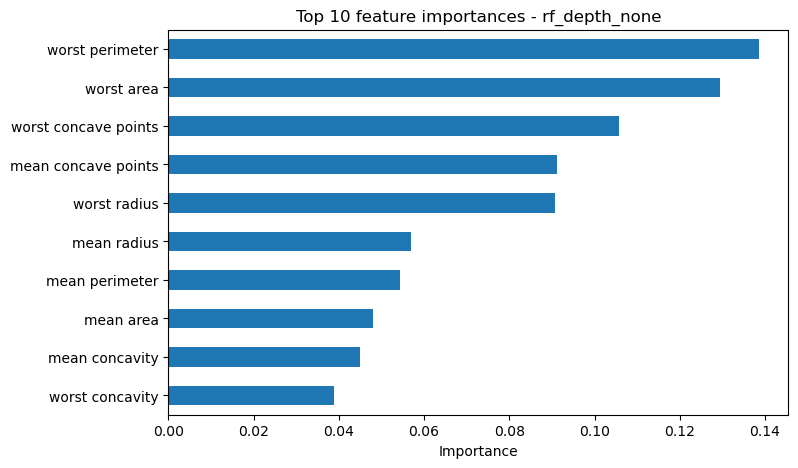

,importance
worst perimeter,0.138543
worst area,0.129319
worst concave points,0.105809
mean concave points,0.091236
worst radius,0.090775
mean radius,0.056911
mean perimeter,0.054352
mean area,0.048119
mean concavity,0.044931
worst concavity,0.038979


In [8]:
importances = pd.Series(
    best_model.feature_importances_, index=X.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
importances.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title(f"Top 10 feature importances - {best_run_name}")
plt.show()

importances.to_frame("importance")


## 7. Saved output files

In [9]:
sorted([p.name for p in output_dir.iterdir()])


['rf_depth_4_metrics.json',
 'rf_depth_4_model.joblib',
 'rf_depth_8_metrics.json',
 'rf_depth_8_model.joblib',
 'rf_depth_none_metrics.json',
 'rf_depth_none_model.joblib']

## Final note

This notebook is a **combined version** prepared for the **Experimental Tracking Lab**.
Instead of the original labs' datasets and models, this version uses:
- a **different dataset**: Breast Cancer Wisconsin dataset
- a **different model**: Random Forest Classifier

The notebook is already structured so that the outputs appear directly under each code cell after execution.
